# Retirement Tax Optimizer — Spouse A & Spouse B (package edition)

**Goal:** maximize after-tax terminal net worth at the planning horizon, subject to never running out of money, by jointly choosing:

1. **Pre-retirement** allocation between Traditional 401(k) and Roth 401(k) for each spouse.
2. **In-retirement** withdrawal sequencing across taxable / pretax / Roth buckets.
3. **Roth-conversion** size during the retirement-to-RMD gap years.

All simulation logic lives in the `tax_optimizer/` Python package. This notebook is a thin orchestration layer that:

- Imports the engine and configures a scenario.
- Runs the four-strategy comparison + tornado sensitivity (deterministic).
- Demonstrates the v2 capabilities:
  - **Monte Carlo** sequence-of-returns risk (`§8`).
  - **Widow's-penalty / single-filer mortality** stress test (`§9`).
  - **Tax-regime change** (TCJA sunset) stress test (`§10`).
  - **Smile-shaped retirement spending** + lump events (`§11`).
  - **Asset location** (per-account equity / bond mix) (`§12`).

To use your own scenario, edit cell `§1` and re-run.


## §1. Scenario inputs

In [1]:
from __future__ import annotations
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tax_optimizer import (
    Config,
    Inputs,
    StartingBalances,
    CurrentIncome,
    CurrentContrib,
    PensionInputs,
    SocialSecurity,
    SpendingProfile,
    SpendingPhase,
    LumpEvent,
    LongTermCareShock,
    AssetLocation,
    AssetMix,
    DeterministicModel,
    LognormalModel,
    BootstrapModel,
    Mortality,
    TCJA_EXTENDED,
    PRE_TCJA_2017,
    SUNSET_2026,
    simulate,
    simulate_paths,
    summarize,
    optimize_s3,
    BRACKET_CHOICES,
    tornado_sensitivity,
    render_actions,
    render_takeaways,
    StrategyResult,
)
from tax_optimizer.tax import federal_tax, irmaa_annual_surcharge

# -- Scenario: typical middle-class dual-income MFJ couple turning 50 in 2026 --
# Defaults reflect median-ish U.S. data for households at peak earning years:
#   - Combined gross ~$145k (Pew middle-class band for a 3-person household).
#   - Retirement balances near the median for age 50 (Vanguard "How America Saves").
#   - No private pension, modest taxable brokerage and HSA.
inputs = Inputs(
    # --- Ages (Spouse A is the simulation anchor for cfg.horizon_age) ----
    spouse_a_age_start=50,           # current age in cfg.start_year (defaults to 2026)
    spouse_b_age_start=50,
    spouse_a_retire_age=65,          # last year of W-2 wages and 401(k) contributions
    spouse_b_retire_age=65,
    # --- 401(k) deferral policy (decision variables for the S3 optimizer) -
    spouse_a_total_contrib_pct=0.08, # fraction of GROSS salary deferred to 401(k)
    spouse_b_total_contrib_pct=0.06,
    spouse_a_roth_401k_pct=0.0,      # share of the deferral routed to Roth (rest = Traditional)
    spouse_b_roth_401k_pct=0.0,
    # --- Today's account balances (in current dollars) -------------------
    starting=StartingBalances(
        spouse_a_pretax_401k=225_000.0,
        spouse_b_pretax_401k=150_000.0,
        spouse_a_roth_ira=40_000.0,     # pooled with B's Roth IRA in state.roth
        spouse_b_roth_ira=0.0,          # documentation-only split; simulator pools both
        spouse_a_pretax_ira=0.0,        # pooled with A's 401(k) in state.spouse_a_pretax (RMDs use A's age)
        spouse_b_pretax_ira=35_000.0,   # pooled with B's 401(k) in state.spouse_b_pretax (RMDs use B's age)
        pension_balance=0.0,            # cash-balance-style pension; 0 if none
        hsa=18_000.0,
        taxable_brokerage=80_000.0,     # cost basis tracked dynamically via cfg.cap_gains_basis_fraction
    ),
    # --- Annual gross income (modeled only during working years) ---------
    income=CurrentIncome(
        spouse_a_gross=95_000.0,       # W-2 wages BEFORE any 401(k) deferral
        spouse_b_gross=70_000.0,
        spouse_a_bonus=5_000.0,        # taxed as ordinary wages; not subject to 401(k) deferral here
        interest=500.0,               # 1099-INT; ordinary rates
        capital_gains=1_000.0,         # realized LTCG; preferential rate
        dividends=2_000.0,              # qualified dividends; preferential rate
    ),
    # --- Payroll-deferral reference data ---------------------------------
    # These fields are reference-only — the actual decision variables
    # (deferral pct, Roth split) live at the top of `Inputs` above. The
    # simulator pulls std_deduction from cfg.tax_regime; HSA contributions
    # and the baseline-tax anchor are not yet wired into the year loop.
    contrib=CurrentContrib(
        spouse_a_pct=0.08,              # informational: starting deferral
        spouse_b_pct=0.06,
        spouse_a_roth_pct=0.0,
        spouse_b_roth_pct=0.0,
        hsa_family=8_550.0,             # 2026 IRS family HSA cap (informational)
        std_deduction=32_200.0,         # 2026 MFJ standard deduction (informational)
        baseline_tax=0.0,               # slot for a hand-checked Year-1 federal tax
    ),
    # --- Defined-benefit / cash-balance pension --------------------------
    # `monthly_at_nrd` = monthly annuity expected at Normal Retirement Date
    # (= cfg.pension_start_age). Leave both 0 if there's no pension.
    pension=PensionInputs(balance_today=0.0, monthly_at_nrd=0.0),
    # --- Social Security -------------------------------------------------
    # Monthly benefit paid once each spouse reaches cfg.ss_start_age. There
    # is no FRA actuarial adjustment in the model, so enter the amount you
    # expect to receive AT the claim age. Survivor inherits the larger of
    # the two monthly amounts when one spouse dies.
    ss=SocialSecurity(monthly_spouse_a=2_700.0, monthly_spouse_b=2_200.0),
    # --- Retirement spending (today's dollars; inflated each year) -------
    annual_expenses=85_000.0,
)

# -- Default Config: deterministic 6% growth, MFJ, horizon age 90 ------------
# `Config` now only carries simulation-level knobs (macro assumptions, age-
# gated policy events, regime / market / spending blocks). The household
# "about me" data — ages, retire ages, contribution rates — lives on
# `Inputs` above so the same `Config` can be reused across households.
cfg = Config(
    annual_expenses_today=inputs.annual_expenses,
    nominal_growth_rate=0.06,    # equity & bond return when market is deterministic
    inflation=0.025,             # CPI; inflates expenses, brackets, SS, IRMAA tiers
    wage_growth=0.030,           # nominal raises applied until each spouse's retire age
    horizon_age=90,              # last simulated age for Spouse A; B's age tracks independently
    ss_start_age=70,             # claim age applied to both spouses (single knob today)
    pension_start_age=65,        # NRD at which pension annuity begins
    # rmd_start_age=75,          # SECURE 2.0 default; change only to model future legislation
)

print('--- Starting balances ---')
for k, v in inputs.starting.__dict__.items():
    print(f'  {k:30s} ${v:>14,.0f}')
print(f'\nAnnual expenses:    ${inputs.annual_expenses:,.0f}')
print(f'Horizon:           {inputs.spouse_a_age_start} -> {cfg.horizon_age}')
print(f'Tax regime:        {cfg.tax_regime.name}')


# --- DataFrame display helper -----------------------------------------------
# `fmt_money(df)` renders `df` with currency / percent / integer formatting
# per known column. Returns a `Styler` (so `df` itself is unchanged) and
# avoids the scientific notation pandas falls back to for large floats.
_DOLLAR_COLS = {
    # year-by-year simulator output
    'wages', 'pension', 'ssn', 'rmd', 'rmd_a', 'rmd_b',
    'roth_conversion', 'roth_conversion_a', 'roth_conversion_b',
    'pretax_withdrawal', 'pretax_withdrawal_a', 'pretax_withdrawal_b',
    'roth_withdrawal', 'taxable_withdrawal',
    'agi', 'taxable_income', 'federal_tax', 'irmaa', 'spending_need',
    'pretax_balance', 'pretax_a_balance', 'pretax_b_balance',
    'roth_balance', 'taxable_balance', 'hsa_balance', 'pension_balance',
    # `summarize()` keys
    'lifetime_tax_npv', 'lifetime_irmaa_npv', 'terminal_after_tax', 'min_balance',
    # `MonteCarloResult.summary()` keys
    'terminal_p5', 'terminal_p25', 'terminal_p50', 'terminal_p75', 'terminal_p95',
    'cvar_terminal_p10', 'cvar_terminal_p20',
    'lifetime_tax_p50', 'lifetime_irmaa_p50',
    # `tornado_sensitivity` deltas
    'delta_low', 'delta_high', 'swing',
}
_PCT_COLS = {'marginal', 'peak_marginal', 'prob_success', 'equity_return', 'bond_return'}
_INT_COLS = {
    'year', 'spouse_a_age', 'spouse_b_age', 'irmaa_tier',
    'years_irmaa', 'peak_irmaa_tier', 'n_paths',
}


def fmt_money(df):
    """Return a Styler that formats `df` for display.

    Dollar columns render as `$1,234,567`, percent columns as `12.3%`,
    integer-coded columns as `1,234`. Unknown columns are left alone.
    `median_ruin_year_offset == -1` (the "no ruin" sentinel) renders as `—`.
    """
    fmt = {}
    for col in df.columns:
        c = str(col)
        if c in _DOLLAR_COLS:
            fmt[col] = '${:,.0f}'
        elif c in _PCT_COLS:
            fmt[col] = '{:.1%}'
        elif c == 'median_ruin_year_offset':
            fmt[col] = lambda v: '—' if v < 0 else f'{v:,.0f}'
        elif c in _INT_COLS:
            fmt[col] = '{:,.0f}'
    return df.style.format(fmt)


--- Starting balances ---
  spouse_a_pretax_401k           $       225,000
  spouse_b_pretax_401k           $       150,000
  spouse_a_roth_ira              $        40,000
  spouse_b_roth_ira              $             0
  spouse_a_pretax_ira            $             0
  spouse_b_pretax_ira            $        35,000
  pension_balance                $             0
  hsa                            $        18,000
  taxable_brokerage              $        80,000

Annual expenses:    $85,000
Horizon:           50 -> 90
Tax regime:        TCJA_extended_2026


## §2. Sanity check — first-year federal tax

Verify the package's federal-tax engine produces sensible numbers
against a hand calculation for the scenario's first working year.


In [2]:
# First-year wages, pre-tax 401(k) deferrals reduce wages_box1.
a_pretax = inputs.income.spouse_a_gross * inputs.contrib.spouse_a_pct
b_pretax = inputs.income.spouse_b_gross * inputs.contrib.spouse_b_pct
wages_box1 = (
    inputs.income.spouse_a_gross + inputs.income.spouse_a_bonus
    + inputs.income.spouse_b_gross
    - a_pretax - b_pretax
)

ftax = federal_tax(
    regime=cfg.tax_regime,
    filing_status='mfj',
    wages=wages_box1,
    interest=inputs.income.interest,
    qualified_div=inputs.income.dividends,
    ltcg=inputs.income.capital_gains,
)
print(f'Year 1 AGI:           ${ftax["agi"]:,.0f}')
print(f'Year 1 taxable inc:   ${ftax["taxable_income"]:,.0f}')
print(f'Year 1 federal tax:   ${ftax["tax"]:,.0f}')
print(f'Year 1 marginal rate: {ftax["marginal"]:.0%}')


Year 1 AGI:           $161,700
Year 1 taxable inc:   $129,500
Year 1 federal tax:   $18,108
Year 1 marginal rate: 22%


## §3. Strategy comparison: S0 / S1 / S2 / S3

Four candidate strategies, all evaluated deterministically (single
6%-growth path). The optimizer (`S3`) uses `differential_evolution`
because the IRMAA cliffs make the objective non-smooth.


In [3]:
s0_cfg, s0_inputs = cfg, inputs
s1_cfg, s1_inputs = cfg, replace(inputs, spouse_a_roth_401k_pct=1.0, spouse_b_roth_401k_pct=1.0)
s2_cfg, s2_inputs = replace(cfg, roth_conversion_target_bracket=0.22), inputs
s3_cfg, s3_inputs, x_opt = optimize_s3(cfg, inputs, objective='terminal')
print(f'S3 optimizer chose:  Spouse A Roth %={s3_inputs.spouse_a_roth_401k_pct:.2f}  '
      f'Spouse B Roth %={s3_inputs.spouse_b_roth_401k_pct:.2f}  '
      f'Conv bracket={s3_cfg.roth_conversion_target_bracket:.0%}')

# Each strategy carries its own (cfg, inputs) pair because the optimizer
# may flip Roth-401(k) splits (which live on Inputs) and bracket-fill
# targets (which live on Config). `StrategyResult` keeps these named so
# downstream consumers don't depend on tuple ordering.
results: dict[str, StrategyResult] = {}
for name, c, inp in [
    ('S0_baseline',        s0_cfg, s0_inputs),
    ('S1_all_roth_401k',   s1_cfg, s1_inputs),
    ('S2_bracket_fill_22', s2_cfg, s2_inputs),
    ('S3_optimized',       s3_cfg, s3_inputs),
]:
    df = simulate(c, inp)
    results[name] = StrategyResult(cfg=c, inputs=inp, df=df, summary=summarize(df))

summary_df = pd.DataFrame({n: r.summary for n, r in results.items()}).T
fmt_money(summary_df[['lifetime_tax_npv', 'lifetime_irmaa_npv', 'terminal_after_tax', 'peak_marginal', 'years_irmaa']])


S3 optimizer chose:  Spouse A Roth %=1.00  Spouse B Roth %=1.00  Conv bracket=22%


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa
S0_baseline,"$567,089","$15,736","$5,629,253",24.0%,12
S1_all_roth_401k,"$571,014","$11,182","$6,998,219",24.0%,10
S2_bracket_fill_22,"$567,946","$26,300","$5,802,487",24.0%,8
S3_optimized,"$558,921","$13,043","$7,223,035",24.0%,5


## §4. Visualizations: balances, taxes, contributions

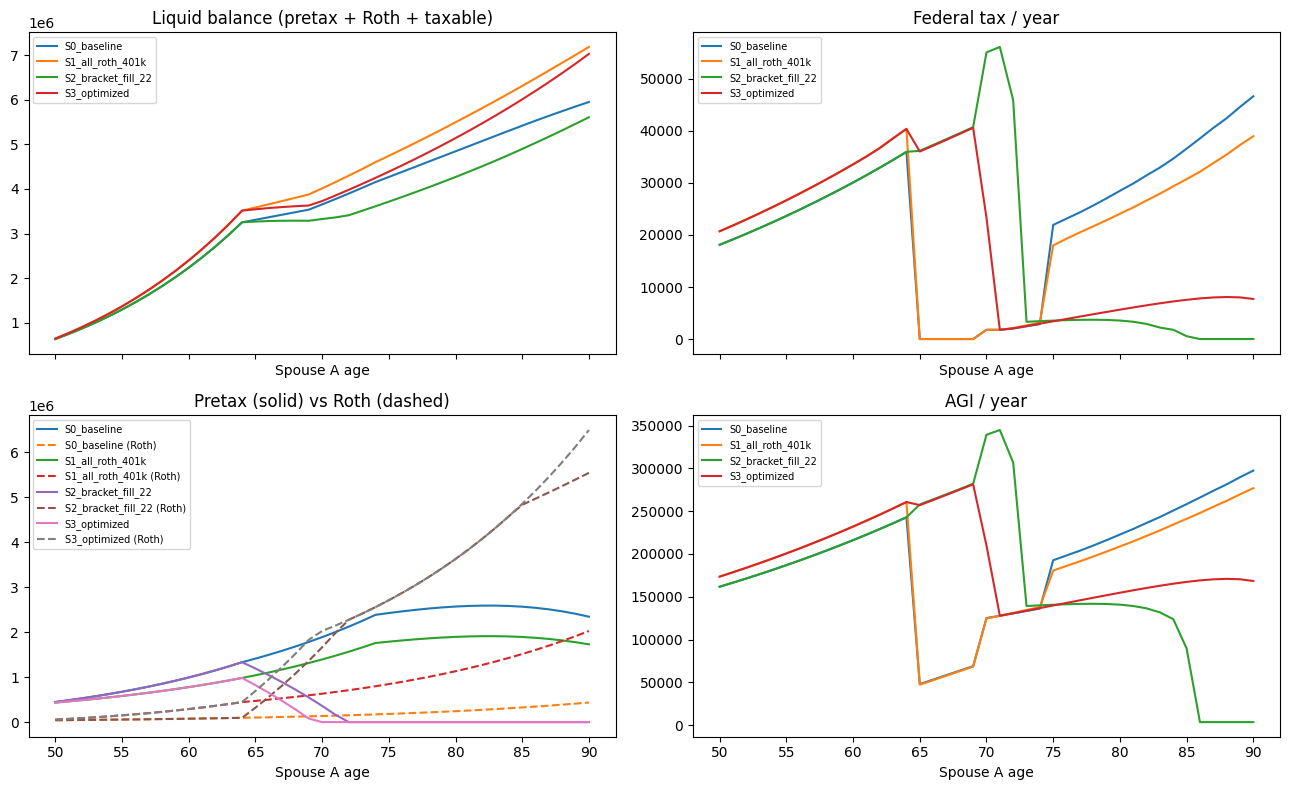

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for name, r in results.items():
    df = r.df
    liquid = df['pretax_balance'] + df['roth_balance'] + df['taxable_balance']
    axes[0,0].plot(df['spouse_a_age'], liquid, label=name)
    axes[0,1].plot(df['spouse_a_age'], df['federal_tax'], label=name)
    axes[1,0].plot(df['spouse_a_age'], df['pretax_balance'], label=name, linestyle='-')
    axes[1,0].plot(df['spouse_a_age'], df['roth_balance'], label=f'{name} (Roth)', linestyle='--')
    axes[1,1].plot(df['spouse_a_age'], df['agi'], label=name)
axes[0,0].set_title('Liquid balance (pretax + Roth + taxable)')
axes[0,1].set_title('Federal tax / year')
axes[1,0].set_title('Pretax (solid) vs Roth (dashed)')
axes[1,1].set_title('AGI / year')
for ax in axes.flat:
    ax.legend(fontsize=7)
    ax.set_xlabel('Spouse A age')
plt.tight_layout()
plt.show()


## §5. Year-by-year detail of the winning strategy

Each row is one simulation year. Key columns:
- `wages` / `pension` / `ssn` — gross income items.
- `rmd_a` / `rmd_b` — required minimum distributions (per IRS Uniform Lifetime).
- `roth_conversion` — pretax → Roth conversion in gap years.
- `pretax_withdrawal` / `taxable_withdrawal` — strategy-driven retirement draws.
- `agi` / `federal_tax` — IRC §1 computation for the active filing status.
- `irmaa` / `irmaa_tier` — Medicare premium surcharge (Tier 0 = no surcharge).
- `marginal` — top federal ordinary bracket reached.
- `*_balance` columns — end-of-year liquid balances per bucket.
- `equity_return` / `bond_return` — that year's draws from the active `MarketModel`
  (constant for `DeterministicModel`, stochastic otherwise).


In [5]:
winner_name = max(results, key=lambda n: results[n].summary['terminal_after_tax'])
winner_df = results[winner_name].df
print(f'Winning strategy: {winner_name}')

show_cols = [
    'year','spouse_a_age','spouse_b_age','filing_status','wages','pension','ssn',
    'rmd_a','rmd_b','roth_conversion','pretax_withdrawal','taxable_withdrawal',
    'agi','federal_tax','irmaa','irmaa_tier','marginal',
    'pretax_a_balance','pretax_b_balance','roth_balance','taxable_balance',
]
fmt = {col: '${:>12,.0f}' for col in show_cols if col not in
       ('year','spouse_a_age','spouse_b_age','filing_status','irmaa_tier')}
fmt['marginal'] = '{:.0%}'
fmt['irmaa_tier'] = '{:>2.0f}'
winner_df[show_cols].iloc[:].style.format(fmt)


Winning strategy: S3_optimized


,year,spouse_a_age,spouse_b_age,filing_status,wages,pension,ssn,rmd_a,rmd_b,roth_conversion,pretax_withdrawal,taxable_withdrawal,agi,federal_tax,irmaa,irmaa_tier,marginal,pretax_a_balance,pretax_b_balance,roth_balance,taxable_balance
0,2026,50,50,mfj,"$ 170,000",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 173,500","$ 20,704",$ 0,0,22%,"$ 238,500","$ 196,100","$ 54,908","$ 155,925"
1,2027,51,51,mfj,"$ 175,100",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 178,600","$ 21,826",$ 0,0,22%,"$ 252,810","$ 207,866","$ 71,086","$ 237,980"
2,2028,52,52,mfj,"$ 180,353",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 183,853","$ 22,982",$ 0,0,22%,"$ 267,979","$ 220,338","$ 88,621","$ 326,574"
3,2029,53,53,mfj,"$ 185,764",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 189,264","$ 24,172",$ 0,0,22%,"$ 284,057","$ 233,558","$ 107,606","$ 422,137"
4,2030,54,54,mfj,"$ 191,336",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 194,836","$ 25,398",$ 0,0,22%,"$ 301,101","$ 247,572","$ 128,140","$ 525,127"
5,2031,55,55,mfj,"$ 197,077",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 200,577","$ 26,661",$ 0,0,22%,"$ 319,167","$ 262,426","$ 150,328","$ 636,032"
6,2032,56,56,mfj,"$ 202,989",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 206,489","$ 27,962",$ 0,0,22%,"$ 338,317","$ 278,172","$ 174,283","$ 755,364"
7,2033,57,57,mfj,"$ 209,079",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 212,579","$ 29,301",$ 0,0,22%,"$ 358,616","$ 294,862","$ 200,124","$ 883,671"
8,2034,58,58,mfj,"$ 215,351",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 218,851","$ 30,681",$ 0,0,22%,"$ 380,133","$ 312,554","$ 227,976","$ 1,021,532"
9,2035,59,59,mfj,"$ 221,811",$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,$ 0,"$ 225,311","$ 32,103",$ 0,0,22%,"$ 402,941","$ 331,307","$ 257,974","$ 1,169,560"


## §6. Tornado sensitivity

Base terminal NW: $5,629,253



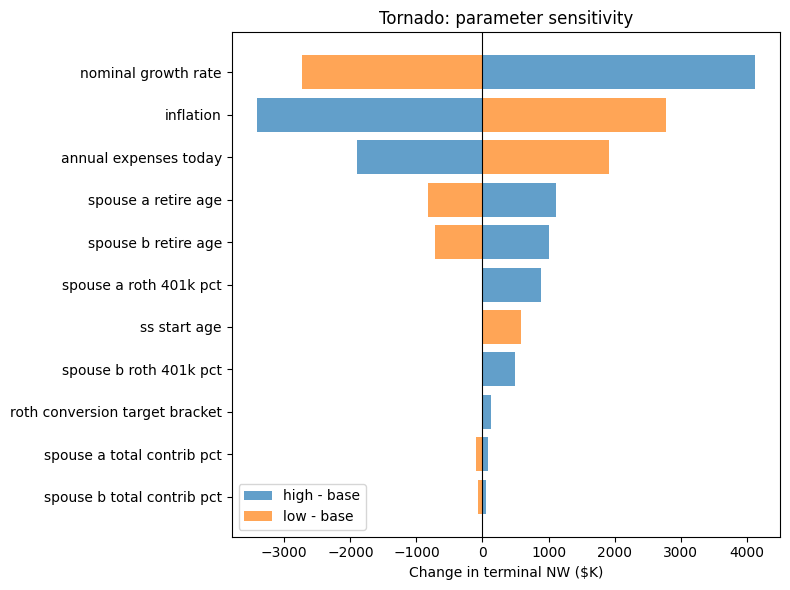

,param,low_value,high_value,delta_low,delta_high,swing
0,nominal_growth_rate,0.050000,0.070000,"$-2,736,042","$4,127,842","$4,127,842"
1,inflation,0.015000,0.035000,"$2,783,734","$-3,419,272","$3,419,272"
2,annual_expenses_today,76500.000000,93500.000000,"$1,916,580","$-1,896,985","$1,916,580"
3,spouse_a_retire_age,63.000000,67.000000,"$-829,480","$1,115,568","$1,115,568"
4,spouse_b_retire_age,63.000000,67.000000,"$-711,775","$1,002,654","$1,002,654"
5,spouse_a_roth_401k_pct,0.000000,1.000000,$0,"$880,053","$880,053"
6,ss_start_age,67.000000,70.000000,"$589,474",$0,"$589,474"
7,spouse_b_roth_401k_pct,0.000000,1.000000,$0,"$486,893","$486,893"


In [6]:
sens_df, base_terminal = tornado_sensitivity(cfg, inputs)
print(f'Base terminal NW: ${base_terminal:,.0f}\n')

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(sens_df))
ax.barh(y, sens_df['delta_high'].values / 1e3, alpha=0.7, label='high - base')
ax.barh(y, sens_df['delta_low'].values / 1e3, alpha=0.7, label='low - base')
ax.set_yticks(y); ax.set_yticklabels(sens_df['param'].str.replace('_', ' '))
ax.invert_yaxis(); ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Change in terminal NW ($K)')
ax.set_title('Tornado: parameter sensitivity'); ax.legend()
plt.tight_layout(); plt.show()
fmt_money(sens_df.head(8))


## §7. Recommended actions + takeaways

In [7]:
print(render_takeaways(results, cfg))
print()
print(render_actions(results, sens_df, cfg, base_terminal))


### Run summary (41-year horizon, ages 50-90)
- Winning strategy: S3_optimized - terminal after-tax NW $7,223,035 (+$1,593,782 vs S0_baseline).
- IRMAA exposure (S3_optimized): 5 year(s), peak tier 2.
- Peak federal marginal rate (S3_optimized): 24%.

### Recommended actions

1. Hybrid plan (optimizer-chosen): set Spouse A Roth-401(k) split to 100% and Spouse B to 100%; target Roth conversions up to the 22% bracket in gap years.
   - Expected lift vs S0_baseline: $1,593,782 terminal after-tax NW.

2. Highest-leverage knobs (top 3 by tornado swing):
   - nominal_growth_rate - swing $4,127,842; pushing it higher adds ~$4,127,842. Market assumption (not an action).
   - inflation - swing $3,419,272; pushing it lower adds ~$2,783,734. Macro assumption only; useful as a stress-test.
   - annual_expenses_today - swing $1,916,580; pushing it lower adds ~$1,916,580. Trim annual spending toward $76,500.

3. Always-good hygiene:
   - Max out the HSA family contribution (triple-tax-advantaged).
 

## §8. Monte Carlo — sequence-of-returns risk

The deterministic simulator above assumes a flat 6%/yr return every year.
That hides "sequence-of-returns risk": a market crash early in retirement
hurts a withdrawing portfolio far more than the same crash late in life.

Below we re-run the same `cfg` with a `LognormalModel` (independent yearly
draws, μ=7%, σ=18% for equities) and a `BootstrapModel` (block-bootstrap
from 1928–2023 historical S&P + 10y-Treasury data). The summary reports:

- `prob_success` — fraction of paths whose liquid balance never falls
  below that year's spending need.
- `terminal_p5/p50/p95` — 5th / median / 95th percentile of terminal
  after-tax NW.
- `cvar_terminal_p10` — average terminal NW across the worst-10% paths
  (the metric a risk-averse retiree should actually optimize on).

Use `simulate_paths(..., n_paths=2000)` for tighter tails; the 200-path
demo below runs in a few seconds.


In [8]:
cfg_lognormal = replace(cfg, market=LognormalModel(equity_mu=0.07, equity_sigma=0.18,
                                                  bond_mu=0.04, bond_sigma=0.06))
cfg_bootstrap = replace(cfg, market=BootstrapModel(block_size=5))

mc_lognormal = simulate_paths(cfg_lognormal, inputs, n_paths=2000, seed=42)
mc_bootstrap = simulate_paths(cfg_bootstrap, inputs, n_paths=2000, seed=42)

mc_summary = pd.DataFrame({
    'lognormal':  mc_lognormal.summary(),
    'bootstrap':  mc_bootstrap.summary(),
}).T
fmt_money(mc_summary)


,n_paths,prob_success,terminal_p5,terminal_p50,terminal_p95,cvar_terminal_p10,cvar_terminal_p20,lifetime_tax_p50,lifetime_irmaa_p50,median_ruin_year_offset
lognormal,"2,000",74.4%,"$22,397","$3,721,459","$42,383,170","$22,043","$39,556","$535,141","$10,876",32
bootstrap,"2,000",96.7%,"$1,785,030","$37,828,715","$228,168,741","$1,973,326","$5,262,091","$1,277,008","$71,835",33


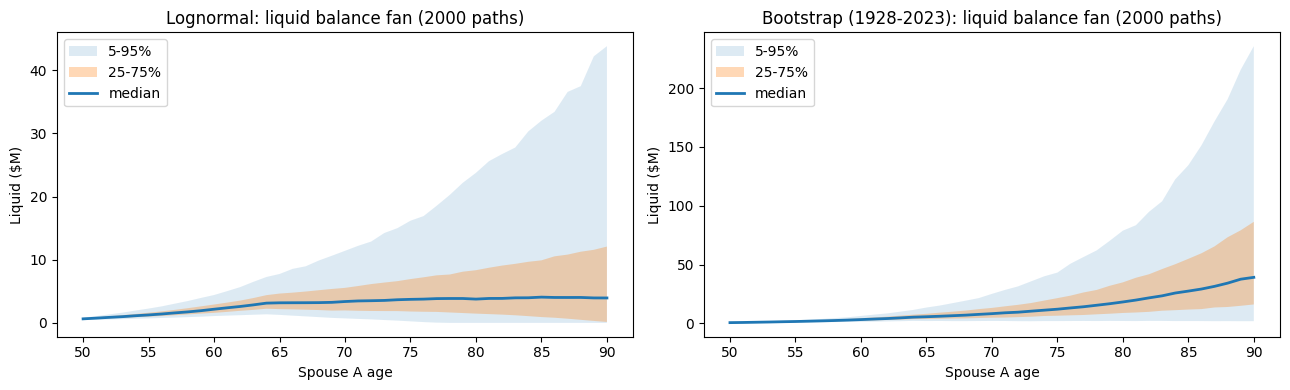

In [9]:
# Fan chart of liquid balance across all 200 paths.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mc, title in [(axes[0], mc_lognormal, 'Lognormal'),
                      (axes[1], mc_bootstrap, 'Bootstrap (1928-2023)')]:
    ages = mc.paths[0]['spouse_a_age'].to_numpy()
    arr = np.stack([
        (df['pretax_balance'] + df['roth_balance'] + df['taxable_balance']).to_numpy()
        for df in mc.paths
    ]) / 1e6
    p5, p25, p50, p75, p95 = [np.percentile(arr, p, axis=0) for p in (5,25,50,75,95)]
    ax.fill_between(ages, p5, p95, alpha=0.15, label='5-95%')
    ax.fill_between(ages, p25, p75, alpha=0.30, label='25-75%')
    ax.plot(ages, p50, lw=2, label='median')
    ax.set_title(f'{title}: liquid balance fan ({mc.n_paths} paths)')
    ax.set_xlabel('Spouse A age'); ax.set_ylabel('Liquid ($M)'); ax.legend()
plt.tight_layout(); plt.show()


## §9. Widow's-penalty stress test

Realistic plans must stress the case where one spouse dies and the
survivor switches from MFJ to single-filer status. The single-filer
penalty:

- Brackets compress (the 22% bracket caps at ~$103k for single vs $207k MFJ).
- Standard deduction halves.
- IRMAA thresholds for Medicare premiums roughly halve.
- Survivor receives only the *larger* of the two SS checks, not both.
- Pension annuity scales by the joint-and-survivor election (default 50%).

Below we model Spouse A dying at year 25 (age 75) and re-run S3.


In [10]:
cfg_widow = replace(s3_cfg, mortality=Mortality(year_of_death_a=25,
                                               pension_survivor_pct=0.5))

df_baseline = results['S3_optimized'].df
df_widow = simulate(cfg_widow, inputs)

cmp = pd.DataFrame({
    'baseline (both alive)': summarize(df_baseline),
    'widow (A dies year 25)': summarize(df_widow),
}).T
fmt_money(cmp)


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa,peak_irmaa_tier,min_balance
baseline (both alive),"$558,921","$13,043","$7,223,035",24.0%,5,2,"$645,433"
widow (A dies year 25),"$594,274","$30,472","$4,971,369",24.0%,16,3,"$635,723"


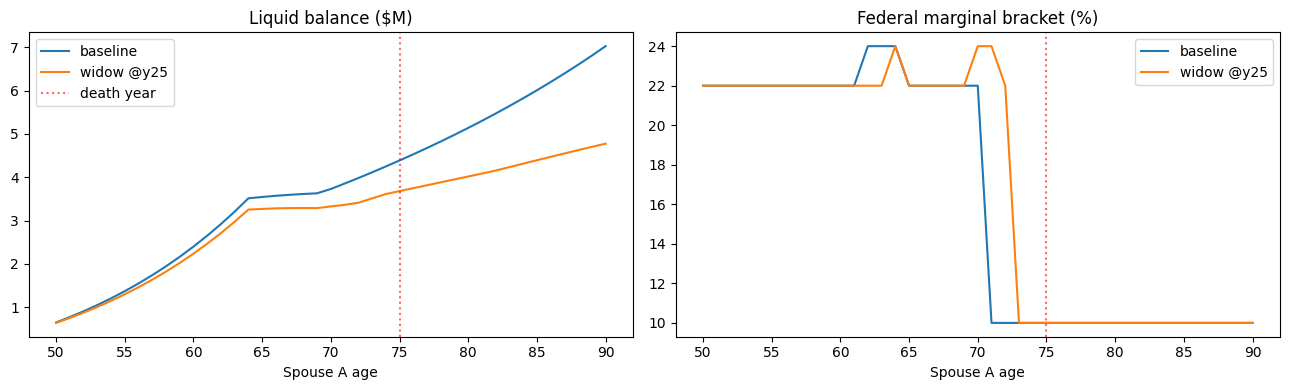

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
liq_b = df_baseline['pretax_balance'] + df_baseline['roth_balance'] + df_baseline['taxable_balance']
liq_w = df_widow['pretax_balance'] + df_widow['roth_balance'] + df_widow['taxable_balance']
axes[0].plot(df_baseline['spouse_a_age'], liq_b/1e6, label='baseline')
axes[0].plot(df_widow['spouse_a_age'], liq_w/1e6, label='widow @y25')
axes[0].axvline(75, color='red', ls=':', alpha=0.6, label='death year')
axes[0].set_title('Liquid balance ($M)'); axes[0].set_xlabel('Spouse A age'); axes[0].legend()
axes[1].plot(df_baseline['spouse_a_age'], df_baseline['marginal']*100, label='baseline')
axes[1].plot(df_widow['spouse_a_age'], df_widow['marginal']*100, label='widow @y25')
axes[1].axvline(75, color='red', ls=':', alpha=0.6)
axes[1].set_title('Federal marginal bracket (%)'); axes[1].set_xlabel('Spouse A age'); axes[1].legend()
plt.tight_layout(); plt.show()


## §10. Tax-regime change — TCJA sunset stress test

The current `TCJA_EXTENDED` regime assumes Congress extends TCJA past
its scheduled 2025 expiration. If TCJA actually expires, brackets revert
to roughly the pre-TCJA structure with widths inflation-adjusted forward
(~1.30× the 2017 nominals; standard deduction roughly halves).

We model this with `regime_change_year_offset` + `regime_change_target`,
swapping to `SUNSET_2026` at year 5 (i.e. starting in 2031).


In [12]:
cfg_sunset = replace(s3_cfg, regime_change_year_offset=5,
                                    regime_change_target=SUNSET_2026)
df_sunset = simulate(cfg_sunset, s3_inputs)

# Re-optimize S3 *under* the sunset assumption to see how the optimizer
# responds — typically conversions become more attractive in years before
# the regime change.
cfg_sunset_base = replace(cfg, regime_change_year_offset=5,
                                regime_change_target=SUNSET_2026)
s3_sunset_cfg, s3_sunset_inputs, _ = optimize_s3(cfg_sunset_base, inputs, objective='terminal')
df_sunset_opt = simulate(s3_sunset_cfg, s3_sunset_inputs)

cmp = pd.DataFrame({
    'baseline (TCJA forever)':       summarize(df_baseline),
    'sunset @y5 (S3 unchanged)':     summarize(df_sunset),
    'sunset @y5 (re-optimized S3)':  summarize(df_sunset_opt),
}).T
fmt_money(cmp)


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa,peak_irmaa_tier,min_balance
baseline (TCJA forever),"$558,921","$13,043","$7,223,035",24.0%,5,2,"$645,433"
sunset @y5 (S3 unchanged),"$707,496","$11,182","$6,259,636",28.0%,10,2,"$645,433"
sunset @y5 (re-optimized S3),"$707,496","$11,182","$6,259,636",28.0%,10,2,"$645,433"


In [13]:
print(f'Original S3 conv target:        {s3_cfg.roth_conversion_target_bracket:.0%}')
print(f'Re-optimized under sunset:      {s3_sunset_cfg.roth_conversion_target_bracket:.0%}')
print(f'Original S3 Roth-401(k) (A/B):  {s3_inputs.spouse_a_roth_401k_pct:.0%} / {s3_inputs.spouse_b_roth_401k_pct:.0%}')
print(f'Re-optimized Roth-401(k) (A/B): {s3_sunset_inputs.spouse_a_roth_401k_pct:.0%} / {s3_sunset_inputs.spouse_b_roth_401k_pct:.0%}')


Original S3 conv target:        22%
Re-optimized under sunset:      0%
Original S3 Roth-401(k) (A/B):  100% / 100%
Re-optimized Roth-401(k) (A/B): 100% / 100%


## §11. Smile-shaped retirement spending + lump events

Real spending follows the Blanchett "retirement smile":

- 100% of base in working years
- 115% of base in the "go-go" years (65–74; travel, hobbies)
- 95% of base in the "slow-go" years (75–84)
- 100% in the "no-go" years (85+) plus an LTC shock in the last 3
  years ($80k/yr today's dollars).

Plus we'll model a $50k wedding gift in year 15 and a $60k new car in year 22.


In [14]:
smile = SpendingProfile.retirement_smile(
    base_spending=inputs.annual_expenses, inflation=0.025,
    ltc_years=3, ltc_annual_today=80_000.0,
)
smile.lump_events = [
    LumpEvent(year_offset=15, amount_today=50_000.0, label='kid wedding'),
    LumpEvent(year_offset=22, amount_today=60_000.0, label='replace car'),
]

cfg_smile = replace(s3_cfg, spending=smile)
df_smile = simulate(cfg_smile, inputs)

cmp = pd.DataFrame({
    'flat $85k (baseline S3)':            summarize(df_baseline),
    'smile + LTC + 2 lump events':        summarize(df_smile),
}).T
fmt_money(cmp)


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa,peak_irmaa_tier,min_balance
flat $85k (baseline S3),"$558,921","$13,043","$7,223,035",24.0%,5,2,"$645,433"
smile + LTC + 2 lump events,"$577,983","$32,477","$3,875,819",24.0%,8,3,"$635,723"


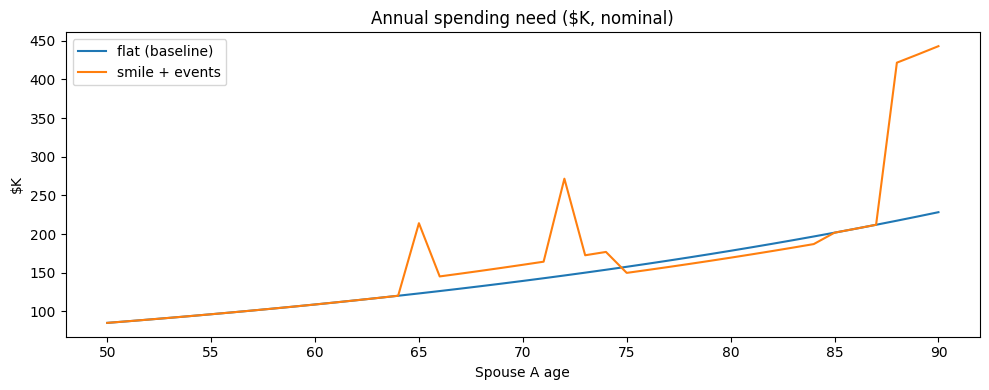

In [15]:
# Show the actual spending need year-by-year so the smile shape is visible.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_baseline['spouse_a_age'], df_baseline['spending_need']/1e3, label='flat (baseline)')
ax.plot(df_smile['spouse_a_age'],    df_smile['spending_need']/1e3,    label='smile + events')
ax.set_title('Annual spending need ($K, nominal)')
ax.set_xlabel('Spouse A age'); ax.set_ylabel('$K'); ax.legend()
plt.tight_layout(); plt.show()


## §12. Asset location — bonds in pretax, equities in Roth

By default the package's `AssetLocation()` puts:

- 40% equity / 60% bond in the **pretax** sleeve  — bonds get sheltered
  from the ordinary-income tax line they would otherwise feed.
- 100% equity in the **Roth** sleeve              — maximize tax-free compounding.
- 80% equity / 20% bond in the **taxable** sleeve.
- 80% equity / 20% bond in the **HSA** sleeve.

Pair that with a `LognormalModel` so equity and bond returns differ
year-to-year, and the asset-location effect becomes visible.


In [16]:
cfg_asset_uniform = replace(s3_cfg, market=LognormalModel(),
                                  asset_location=AssetLocation.uniform(equity_pct=0.6))
cfg_asset_located = replace(s3_cfg, market=LognormalModel(),
                                  asset_location=AssetLocation())   # bonds-in-pretax default

mc_uniform = simulate_paths(cfg_asset_uniform, inputs, n_paths=200, seed=7)
mc_located = simulate_paths(cfg_asset_located, inputs, n_paths=200, seed=7)

cmp = pd.DataFrame({
    'uniform 60/40 everywhere':           mc_uniform.summary(),
    'asset-located (bonds in pretax)':    mc_located.summary(),
}).T
fmt_money(cmp)


,n_paths,prob_success,terminal_p5,terminal_p50,terminal_p95,cvar_terminal_p10,cvar_terminal_p20,lifetime_tax_p50,lifetime_irmaa_p50,median_ruin_year_offset
uniform 60/40 everywhere,200,87.0%,"$59,767","$3,186,410","$17,329,925","$65,605","$298,539","$527,572","$18,211",38
asset-located (bonds in pretax),200,83.0%,"$48,943","$3,177,152","$27,650,596","$49,192","$133,414","$528,209","$17,917",35


## §13. Action report — optimized scenario

A decision-ready summary that pulls together the winning strategy from §3,
the year-by-year detail from §5, the tornado from §6, and (if run) the
Monte Carlo risk picture from §8 into one tailored document.

The cell below regenerates the report from whatever variables are in
scope, so re-running with a different scenario or a different optimizer
objective will produce an updated plan automatically.


In [17]:
from IPython.display import Markdown, display
from datetime import datetime
from pathlib import Path

# Use the canonical `build_action_report` from the package so this notebook
# and the `python -m tax_optimizer` CLI render byte-identical reports.
# Future updates to the report only need to land in one place
# (`tax_optimizer/report.py`).
from tax_optimizer import build_action_report

# Pull Monte Carlo from the lognormal run if it's been computed; otherwise
# the risk section is omitted gracefully.
try:
    _mc_for_report = mc_lognormal
except NameError:
    _mc_for_report = None

_report_md = build_action_report(
    cfg=cfg,
    inputs=inputs,
    results=results,
    sens_df=sens_df,
    base_terminal=base_terminal,
    mc=_mc_for_report,
)
display(Markdown(_report_md))

# Persist two copies: a stable `action_report.md` at the project root for
# quick reference, and a timestamped archive in `reports/` so re-runs
# don't clobber prior plans.
_now = datetime.now()
_generated_at = _now.strftime('%Y-%m-%d %H:%M:%S')
_filename_stamp = _now.strftime('%Y-%m-%d_%H%M%S')

_reports_dir = Path('reports')
_reports_dir.mkdir(exist_ok=True)

_body = (
    f'<!-- Generated {_generated_at} from tax_optimizer_standalone.ipynb -->\n\n'
    + _report_md + '\n'
)

_latest_path  = Path('action_report.md').resolve()
_archive_path = (_reports_dir / f'action_report_{_filename_stamp}.md').resolve()
_latest_path.write_text(_body, encoding='utf-8')
_archive_path.write_text(_body, encoding='utf-8')

print('Saved Markdown report to:')
print(f'  latest:  {_latest_path}')
print(f'  archive: {_archive_path}')


# Retirement Tax Optimization — Action Plan

_41-year horizon, ages 50/50 to 90, tax regime `TCJA_extended_2026`._

## 1. Household snapshot

| Item | Value |
|---|---:|
| Spouse A age (retire / SS) | 50 (65 / 70) |
| Spouse B age (retire / SS) | 50 (65 / 70) |
| Combined gross W-2 income | $170,000 |
| Annual expenses (today's $) | $85,000 |
| Total liquid + retirement assets | $548,000 |
| &nbsp;&nbsp;&nbsp; Spouse A pretax (401k + IRA) | $225,000 |
| &nbsp;&nbsp;&nbsp; Spouse B pretax (401k + IRA) | $185,000 |
| &nbsp;&nbsp;&nbsp; Roth (both spouses, pooled) | $40,000 |
| &nbsp;&nbsp;&nbsp; Taxable brokerage | $80,000 |
| &nbsp;&nbsp;&nbsp; HSA / pension cash-balance | $18,000 / $0 |

## 2. Recommended plan

**Winning strategy:** `S3_optimized`

| Lever | Recommended | Currently |
|---|---:|---:|
| Spouse A 401(k) deferral | 8% of salary | 8% |
| &nbsp;&nbsp; ↳ Roth share of that deferral | 100% | 0% |
| Spouse B 401(k) deferral | 6% of salary | 6% |
| &nbsp;&nbsp; ↳ Roth share of that deferral | 100% | 0% |
| Roth conversion target bracket (gap years) | 22% | 0% |
| Withdrawal strategy in retirement | `conventional` | `conventional` |

## 3. Expected outcomes (deterministic, point-estimate)

_For terminal NW higher is better (↑); for tax / IRMAA lower is better (↓)._

| Metric | Optimized | Baseline (S0) | Δ vs S0 | Direction |
|---|---:|---:|---:|:---:|
| Terminal after-tax NW | $7,223,035 | $5,629,253 | +$1,593,782 | ✅ |
| Lifetime federal tax (NPV) | $558,921 | $567,089 | −$8,168 | ✅ |
| Lifetime IRMAA (NPV) | $13,043 | $15,736 | −$2,693 | ✅ |
| Peak federal marginal rate | 24% | 24% | — | — |
| Years with IRMAA surcharge | 5 | 12 | — | ✅ |
| Peak IRMAA tier | 2 | 2 | — | — |

_Peak federal marginal year: age **62**, AGI ~$245,879, marginal **24%**._

## 4. Risk picture (Monte Carlo)

_Based on 2000 stochastic paths under the `LognormalModel` market model._

| Metric | Value | Reading |
|---|---:|---|
| Probability of success | 74.4% | watch — below 90% |
| Terminal NW p5 / p50 / p95 | $22,397 / $3,721,459 / $42,383,170 | spread of bad-to-good outcomes |
| CVaR(10%) terminal | $22,043 | expected NW in the worst 10% of paths |
| Median lifetime tax (NPV) | $535,141 | — |
| Median ruin year | 32 | **at least half of failure paths run out by year 32** |

## 5. Highest-leverage levers (top 3 by tornado swing)

| Knob | Range tested | Best direction | $ swing |
|---|---|---|---:|
| `nominal_growth_rate` | 5% → 7% | higher (+$4,127,842) | $4,127,842 |
| `inflation` | 2% → 4% | lower (+$2,783,734) | $3,419,272 |
| `annual_expenses_today` | $76,500 → $93,500 | lower (+$1,916,580) | $1,916,580 |

## 6. Year-by-year action timeline

| Phase | Ages (Spouse A) | What to do |
|---|---|---|
| **Accumulation** | 50–64 | Defer 8% of A's salary (100% Roth / 0% Traditional) and 6% of B's (100% Roth / 0% Traditional). Max HSA. Build 1–2 years' expenses in taxable as IRMAA buffer. |
| **Gap years (conversion window)** | 65–74 | No wages and SS not yet started → fill the 22% bracket each year via pretax → Roth conversions. Pay conversion tax from taxable. |
| **Medicare / IRMAA** | 65+ | IRMAA tiers depend on AGI from **2 years prior**. Watch the 22% / 24% bracket and the IRMAA cliffs at 65, 67. |
| **SS claim** | 70 | Both spouses begin Social Security ($58,800/yr today). After this, conversion-window income includes SS. |
| **RMDs begin** | 75 | Required minimum distributions hit Spouse A's pretax balance. Spouse B's RMDs follow on B's schedule. Reduce or stop conversions. |
| **Drawdown** | 76–90 | Withdrawal sequence: `conventional`. Take RMDs first, then top up from taxable / Roth as needed. |

## 7. Year-by-year withdrawal & conversion plan

_Retirement years only. Pre-retirement years are pure accumulation (contributions, no withdrawals or conversions). Cells with no activity render as `—`._

| Age (A) | Pretax W/D | Roth conv. | Roth W/D | Taxable W/D | RMD | AGI | Fed tax | IRMAA |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 65 | $0 | $206,700 | — | $130,918 | — | $257,009 | $36,031 | $2,105 |
| 66 | — | $206,700 | — | $135,114 | — | $262,958 | $37,149 | $2,105 |
| 67 | — | $206,700 | — | $139,402 | — | $268,985 | $38,282 | $5,287 |
| 68 | — | $206,700 | — | $143,783 | — | $275,089 | $39,430 | $5,287 |
| 69 | — | $206,700 | — | $148,259 | — | $281,271 | $40,592 | $5,287 |
| 70 | — | $79,827 | — | $151,285 | — | $209,819 | $23,303 | — |
| 71 | — | — | $0 | $144,542 | — | $127,844 | $1,778 | — |
| 72 | — | — | — | $148,386 | — | $130,728 | $2,052 | — |
| 73 | — | — | $0 | $152,493 | — | $133,725 | $2,502 | — |
| 74 | — | — | — | $156,696 | — | $136,740 | $2,954 | — |
| 75 | — | — | — | $160,993 | — | $139,764 | $3,408 | — |
| 76 | — | — | $0 | $165,386 | — | $142,791 | $3,862 | — |
| 77 | — | — | $0 | $169,878 | — | $145,811 | $4,315 | — |
| 78 | — | — | $0 | $174,467 | — | $148,812 | $4,765 | — |
| 79 | — | — | $0 | $179,154 | — | $151,779 | $5,210 | — |
| 80 | — | — | — | $183,940 | — | $154,693 | $5,647 | — |
| 81 | — | — | $0 | $188,823 | — | $157,529 | $6,072 | — |
| 82 | — | — | — | $193,801 | — | $160,259 | $6,482 | — |
| 83 | — | — | $0 | $198,871 | — | $162,841 | $6,869 | — |
| 84 | — | — | — | $204,029 | — | $165,225 | $7,227 | — |
| 85 | — | — | $0 | $209,266 | — | $167,340 | $7,544 | — |
| 86 | — | — | — | $214,573 | — | $169,091 | $7,807 | — |
| 87 | — | — | $0 | $219,929 | — | $170,341 | $7,994 | — |
| 88 | — | — | — | $225,310 | — | $170,889 | $8,076 | — |
| 89 | — | — | $0 | $230,669 | — | $170,415 | $8,005 | — |
| 90 | — | — | $0 | $235,930 | — | $168,379 | $7,700 | — |

_Pretax W/D = combined Spouse A + B pretax withdrawals; RMD = the IRS-required floor (A and B combined). Roth conversions show up as AGI in the same row but produce no cash to the household — they shift dollars from pretax → Roth and the conversion tax is paid from taxable._

## 8. Always-good hygiene

- **Max the HSA each year** (triple tax-advantaged: deductible, tax-free growth, tax-free qualified withdrawals).
- **Hold 1–2 years of expenses in taxable** as an IRMAA / sequence-of-returns buffer; it lets you avoid IRA withdrawals in down-market years and to manage AGI around IRMAA cliffs.
- **Re-run this annually** with updated balances, salaries, and tax-regime assumptions. Roth-conversion targets in particular are very sensitive to bracket changes.
- **Beneficiary review:** primary + contingent on every account, including the HSA (which becomes ordinary income to a non-spouse beneficiary).

## 9. Caveats — what this plan does NOT model

- **State income tax.** Federal-only today. Add a state-tax overlay if your state taxes retirement income (CA, NY, MA, etc.).
- **ACA premium-tax-credit cliffs** in the 60–64 pre-Medicare years (can dwarf federal-bracket optimization for some households).
- **Estate / step-up basis** beyond the simple 22% pretax haircut in `terminal_after_tax_nw`. Inherited-IRA 10-year-rule treatment is not modeled.
- **Health-care shocks** beyond a single optional LTC stress test.
- **Tax-law revisions** beyond the bundled regimes (`TCJA_EXTENDED`, `PRE_TCJA_2017`, `SUNSET_2026`). Re-run with `cfg.tax_regime = SUNSET_2026` to stress-test current-law sunset.

_This is decision-support output, not tax/legal/investment advice. Consult a qualified professional before acting._

Saved Markdown report to:
  latest:  /Users/vijayyepuri/sources/repos/Tax_Optimizer/action_report.md
  archive: /Users/vijayyepuri/sources/repos/Tax_Optimizer/reports/action_report_2026-05-07_093549.md


## Recap — what changed in v2

| Capability | Where to set it | Effect on output |
|---|---|---|
| Stochastic returns | `cfg.market = LognormalModel(...)` | adds `prob_success`, percentile / CVaR metrics |
| Mortality / widow's penalty | `cfg.mortality = Mortality(year_of_death_a=...)` | flips filing status to single after death; SS / pension scale per election |
| Asset location | `cfg.asset_location = AssetLocation(...)` | per-account equity/bond split — bonds in pretax, equities in Roth |
| Smile spending + lumps | `cfg.spending = SpendingProfile.retirement_smile(...)` | per-age multipliers + lump events + LTC shock |
| Tax regime swap | `cfg.tax_regime`, `cfg.regime_change_year_offset` + `regime_change_target` | per-year regime selection |
| Optimizer objective | `optimize_s3(cfg, inputs, objective='cvar')` | CVaR or `'p_success'` instead of point-estimate terminal NW |

The `tax_optimizer/` package is the single source of truth — every cell
in this notebook imports from it. Run `python -m tax_optimizer --help`
for the equivalent CLI invocation.
